In [1]:
import numpy as np
import pandas as pd
import random
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from skmultilearn.problem_transform import LabelPowerset
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import hamming_loss
from sklearn.metrics import classification_report
from itertools import product
import statsmodels.api as sm

import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, dataframe_describe

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P1'
p = P.lower()

# file1 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_OP_2010_2023.csv'
# file2 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_OP_2010_2023.csv'
file3 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thrace\GR_Thrace_WNV_Dataset_OP_2010_2023.csv'
# file4 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Attica\GR_Attica_WNV_Dataset_OP_2010_2023.csv'

# dataset1 = read_data(file1)
# dataset2 = read_data(file2)
dataset3 = read_data(file3)
# dataset4 = read_data(file4)


# dataset1.head()

# dataset2.head()

dataset3.head()

# dataset4.head()

# dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])
dataset = dataset3

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(840, 112)


In [2]:
dataset.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL511,2010,1,26.176106,41.222160,0.212907,0.037536,-0.140197,-0.037536,0.201926,0.032885,-0.136198,-0.032885,0.036767,0.041530,0.058430,0.041530,10.257397,5.319432,9.448205,14.314735,14.314735,4.733490,-0.739066,2.375193,0.624374,0.624374,7.495444,2.290183,5.911699,7.469555,7.469555,1.815500,14.229300,11.651058,77.314115,176.318629,359.651239,1692.476395,36.348039,1.172517,15.333333,21.500000,43.877551,925.726578,41.0,-8.0,49.0,4.333333,26.666667,26.666667,4.333333,1688.0,361.0,6.0,66.840173,765.0,161.0,161.0,765.0,31,36,30,12,12,3,5,8,13581.052390,1447.622811,7.553922,157.133302,187.594809,178.214108,0.002440,63.381312,352.814714,2.251510,0,43.594740,1.494305,131.360703,0.0,1.0,38257.132795,4360.821676,32,310.557776,1128.121868,199.922173,0.445545,4603.589125,8347.692846,1068.043290,6.228967,49.884013,174.448966,6.441070,0.031303,347.154467,10968.0,50216.0,14937.0,76121.0,9925.0,43408.0,18383.0,71716.0,2311.10,1428.0,1397.0,0
1,EL512,2010,1,24.892059,41.169359,0.301065,-0.016614,-0.299816,0.016614,0.287990,-0.020438,-0.288824,0.020438,0.046475,0.052463,0.075413,0.052463,12.922081,6.769895,8.424589,14.517815,14.517815,4.707540,-0.479640,1.864893,1.117661,1.117661,8.814810,3.145128,5.144741,7.817738,7.817738,3.180500,14.693500,9.796280,44.175999,88.094992,301.865542,1706.160895,31.000000,1.000000,14.541667,18.916667,46.138211,792.137021,36.0,-5.0,41.0,5.333333,23.833333,24.000000,5.333333,1700.0,303.0,30.0,59.851570,735.0,222.0,237.0,623.0,31,36,30,12,12,3,4,4,18108.962476,1475.563032,12.050000,170.212609,382.623456,181.529172,0.000000,19.618243,1422.320233,2.995414,0,68.560816,3.374522,142.346950,0.0,1.0,31452.211279,3842.305182,37,293.788914,1370.096160,209.810542,0.000000,436.495406,8155.090858,1018.304328,9.318418,52.358720,322.604031,11.936875,0.000000,56.801683,10590.0,37198.0,7334.0,55122.0,9955.0,36599.0,9263.0,55817.0,1544.09,1495.0,1597.0,0
2,EL513,2010,1,25.520366,41.111582,0.168641,-0.002557,-0.144486,0.002557,0.161442,0.001173,-0.136416,-0.001173,0.039250,0.042357,0.065412,0.042357,11.885453,7.231715,8.701025,14.774006,14.774006,4.907539,0.014150,2.438802,1.236478,1.236478,8.396496,3.622932,5.569914,8.005242,8.005242,4.038065,15.627742,10.958125,23.452482,92.947734,337.903445,1655.149838,31.000000,1.000000,15.750000,20.500000,46.590909,890.735141,40.0,-4.0,44.0,5.500000,26.666667,26.666667,5.333333,1648.0,339.0,9.0,66.126590,772.0,158.0,158.0,603.0,31,36,30,12,12,3,5,8,20246.356174,1294.419839,9.032258,172.855153,244.919493,181.632017,0.002082,37.490865,309.608445,13.084090,0,51.239071,2.443469,158.49

In [3]:
dataset = encode_cyclical(dataset, 'month', 12)

In [4]:
dataset.cases.sum()

282

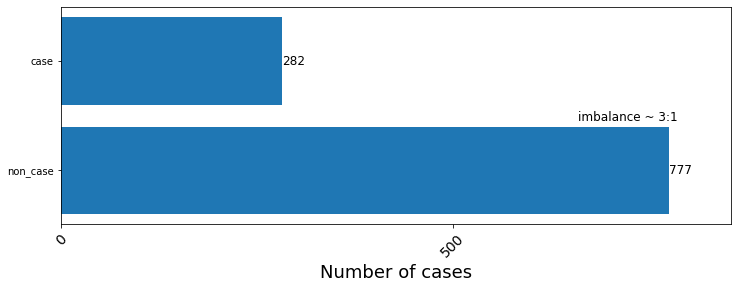

In [5]:
plot_imbalance(dataset, target_column='cases')

In [6]:
#dataset = dataset.query('month >= 5 & month <= 11')
dataset = dataset.query('month >= 5')
dataset.reset_index(drop=True, inplace=True)

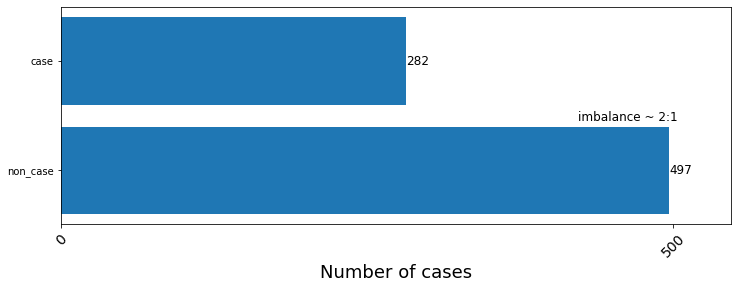

In [7]:
plot_imbalance(dataset, target_column='cases')

In [8]:
dataset.shape

(560, 114)

In [9]:
dataset.cases.sum()

282

In [10]:
dsc = dataframe_describe(dataset, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,39,1,40,39.00%
1,2011,40,0,40,inf%
2,2012,33,76,109,0.43%
3,2013,34,27,61,1.26%
4,2014,36,11,47,3.27%
5,2015,40,0,40,inf%
6,2016,40,0,40,inf%
7,2017,40,0,40,inf%
8,2018,35,14,49,2.50%
9,2019,27,91,118,0.30%


In [11]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases'])
y = dataset['cases']

In [12]:
n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
#k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [49]:
features_to_remove = ['males_15t64', 'females_gt65', 'bio3', 'males_gt65', 'mosq_pred_acc',
       'bio15', 'lst_jan_night_mean', 'fs_area_1km_max',
       'hillshade_mean_1km_max', 'elevation_mean_1km_max',
       'aspect_mean_200m_max', 'distance_to_river_max', 'slope_mean_1km_max',
       'flow_accu_200m_max', 'distance_to_coast_max', 'flow_accu_200m_min',
       'fs_area_1km_min', 'hillshade_mean_1km_min', 'females_lt15',
       'distance_to_river_std', 'distance_to_coast_std', 'slope_mean_1km_std',
       'aspect_mean_200m_std', 'elevation_mean_1km_std',
       'hillshade_mean_1km_std', 'fs_area_1km_std', 'males_total',
       'females_total', 'flow_accu_200m_std', 'aspect_mean_200m_min',
       'mio_eur', 'elevation_mean_1km_min', 'bio19', 'slope_mean_1km_min',
       'lc_prop1', 'ndwi_mean', 'lst_mar_day_mean', 'lst_apr_day_mean',
       'lst_feb_night_mean', 'lst_apr_night_mean', 'lst_apr_mean',
       'rainfall_mean', 'acc_rainfall_month', 'mosq_pred_mean', 'bio5', 'bio7',
       'bio13', 'bio14', 'bio18', 'lc_prop2', 'distance_to_river_min',
       'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_min']


features_to_remove = features_to_remove + ['x', 'y', 'year', 'month']
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

['ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_night_mean', 'lst_mar_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'monthly_lst_min', 'monthly_lst_max', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan', 'bio1', 'bio2', 'bio4', 'bio6', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio16', 'bio17', 'lc_type5', 'males_lt15', 'females_15t64', 'l_total', 'unl_total', 'month_sin', 'month_cos']


In [50]:
print(f"Total Features Used: {len(feature_names)}")

Total Features Used: 43


In [51]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train = convert_multiple_cases(data_train, target_col='cases')
    #data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives = data_train['cases'].value_counts().get(0)
    sum_positives = data_train['cases'].value_counts().get(1)

    params = {
        "objective": "binary:logistic",
        "device": "gpu", 
        "eval_metric": "logloss",
        "learning_rate": 0.1,
        "min_split_loss": 0.5,
        "max_depth": 2, 
        "reg_alpha": 0.5,
        "reg_lambda": 0.5,
        "min_child_weight": 1.5,
        "scale_pos_weight": sum_negatives/sum_positives, 
    }


    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])

    y_train = data_train['cases']
    y_test = data_test['cases']

    print(f"Training set 0/1 Ratio: {(data_train['cases'].value_counts().get(0) / data_train['cases'].value_counts().get(1)):.2f}")
    print(f"Test set 0/1 Ratio: {(data_test['cases'].value_counts().get(0) / data_test['cases'].value_counts().get(1)):.2f}")
    print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
    scaler = MinMaxScaler(feature_range = (-1, 1))
    #scaler = RobustScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    model = xgb.XGBClassifier(**params)   
    trained_model = model.fit(X_train_imputed, y_train)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Fold: 1/10
Training set 0/1 Ratio: 1.80
Test set 0/1 Ratio: 8.33
Weight: 1.80
Fold: 2/10
Training set 0/1 Ratio: 1.72
Test set 0/1 Ratio: 8.33
Weight: 1.72
Fold: 3/10
Training set 0/1 Ratio: 1.70
Test set 0/1 Ratio: 8.33
Weight: 1.70
Fold: 4/10
Training set 0/1 Ratio: 1.70
Test set 0/1 Ratio: 8.33
Weight: 1.70
Fold: 5/10
Training set 0/1 Ratio: 1.70
Test set 0/1 Ratio: 8.33
Weight: 1.70
Fold: 6/10
Training set 0/1 Ratio: 1.68
Test set 0/1 Ratio: 8.33
Weight: 1.68
Fold: 7/10
Training set 0/1 Ratio: 1.69
Test set 0/1 Ratio: 8.33
Weight: 1.69
Fold: 8/10
Training set 0/1 Ratio: 1.76
Test set 0/1 Ratio: 7.00
Weight: 1.76
Fold: 9/10
Training set 0/1 Ratio: 1.84
Test set 0/1 Ratio: 7.00
Weight: 1.84
Fold: 10/10
Training set 0/1 Ratio: 2.12
Test set 0/1 Ratio: 7.00
Weight: 2.12


In [52]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [53]:
train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.0840
Test Loss: 0.2156


In [54]:
classification_thresholds = optimal_threashold_fbeta_scalar(y_train_proba[:,1], y_train_true, beta = 2, round_factor = 2)
print(classification_thresholds)

0.43


In [55]:
thr = classification_thresholds

In [56]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)

In [57]:
print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.96      0.92      0.94       497
           1       0.53      0.67      0.59        63

    accuracy                           0.89       560
   macro avg       0.74      0.80      0.76       560
weighted avg       0.91      0.89      0.90       560



In [58]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[459  38]
 [ 21  42]]


In [59]:
data_train_shap = dataset.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)


In [60]:
# Tree explainer

# curently not working with multioutput models

params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
#tree_shap_values = tree_explainer.shap_values(X_train_imputed)
tree_shap_values = tree_explainer(X_train_imputed)

In [61]:
# shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_OP_2010-2023_Tree_Shapely_Values.npz'

# np.savez(shap_values_path, *tree_shap_values)

# # shap_values = []
# # loaded_shap_values = np.load(shap_values_path)

# # for key in loaded_shap_values.keys():
# #     shap_values.append(loaded_shap_values[key])

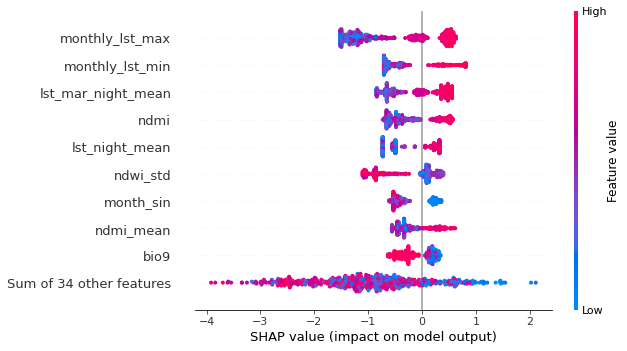

In [62]:
shap.plots.beeswarm(shap_values = tree_shap_values, max_display=10)

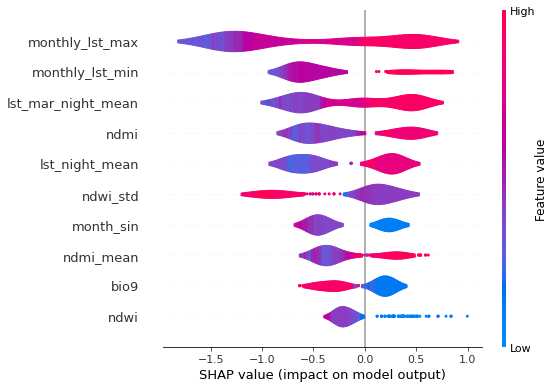

In [63]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='violin', max_display=10)

In [64]:
shap_lim = (-1.5, 1)

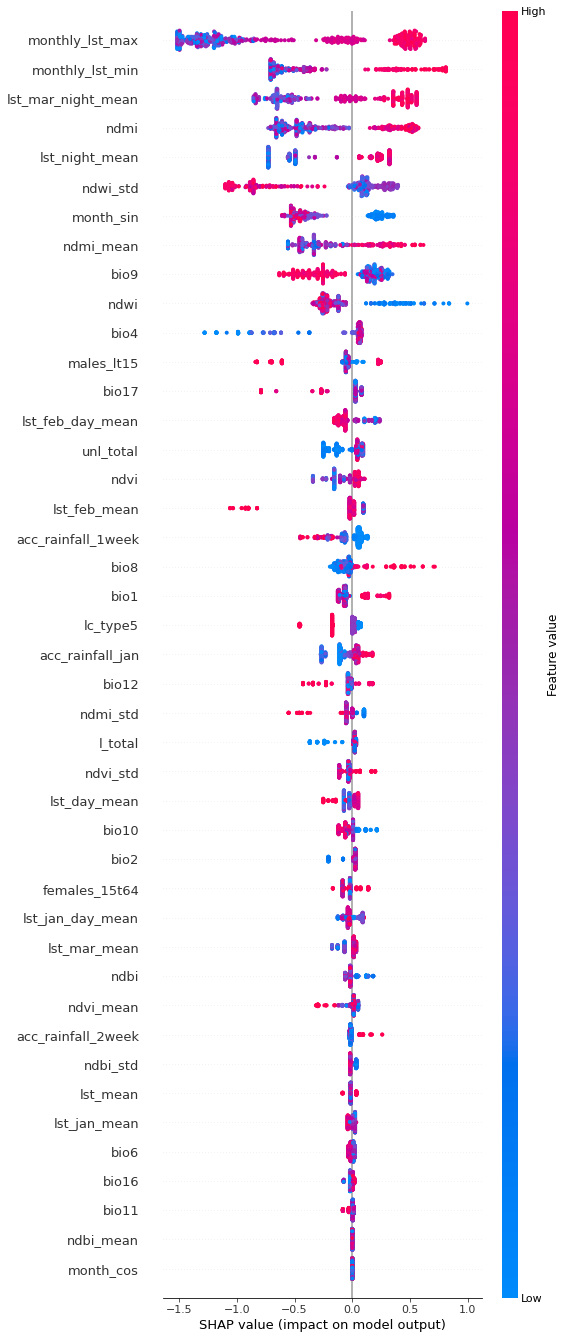

In [65]:
shap.summary_plot(tree_shap_values.values, feature_names = X_train.columns, features = tree_shap_values.data, max_display=110)

In [67]:
# sorted_mean_abs_values_idx[-66:-1]

In [68]:
location_columns = data_train_shap.iloc[:, :5]
wnv_columns = data_train_shap['cases']

In [69]:
tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

In [70]:
X_train

,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_night_mean,lst_mar_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,monthly_lst_min,monthly_lst_max,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,bio1,bio2,bio4,bio6,bio8,bio9,bio10,bio11,bio12,bio16,bio17,lc_type5,males_lt15,females_15t64,l_total,unl_total,month_sin,month_cos
0,0.393937,0.128596,-0.238862,-0.128596,0.387009,0.132557,-0.132557,0.045475,0.047654,0.038540,0.047654,21.656867,5.270557,7.940273,6.760653,3.364297,14.208760,5.445383,4.004454,8.969876,3.820600,26.127200,3.407596e-01,3.109827e+01,856.169093,15.333333,21.500000,925.726578,-8.0,4.333333,26.666667,26.666667,4.333333,1688.0,765.0,161.0,8,10968.0,43408.0,1428.0,1397.0,5.000000e-01,-0.866025
1,0.380403,0.113657,-0.260237,-0.113657,0.368348,0.114479,-0.114479,0.053809,0.073865,0.064012,0.073865,21.040292,6.401194,8.602662,7.021825,2.907331,14.031058,3.754185,4.811161,9.080629,5.137000,26.114500,4.776161e+00,2.198213e+01,694.262047,14.541667,18.916667,792.137021,-5.0,5.333333,23.833333,24.000000,5.333333,1700.0,735.0,222.0,4,10590.0,36599.0,1495.0,1597.0,5.000000e-01,-0.866025
2,0.367630,0.068381,-0.293460,-0.068381,0.362818,0.067988,-0.067988,0.059869,0.064466,0.049366,0.064466,23.067274,6.239366,9.374245,7.433183,3.078465,15.250228,3.804707,5.183781,9.112399,4.723548,26.850484,1.388202e+00,3.124790e+01,728.079692,15.750000,20.500000,890.735141,-4.0,5.500000,26.666667,26.666667,5.333333,1648.0,772.0,158.0,8,8312.0,37741.0,962.0,996.0,5.000000e-01,-0.866025
3,0.312043,0.156578,-0.137646,-0.156578,0.324401,0.149616,-0.149616,0.049437,0.074523,0.083448,0.074523,19.377219,4.279788,5.064072,6.158429,1.703172,12.767824,2.068316,2.473150,7.557022,4.403988,23.747055,1.450752e+01,2.856436e+01,588.609189,12.750000,18.333333,817.284862,-8.0,3.000000,22.500000,22.500000,3.000000,1562.0,609.0,267.0,4,7608.0,29625.0,4198.0,3597.0,5.000000e-01,-0.866025
4,0.387797,0.078941,-0.286932,-0.078941,0.382110,0.106256,-0.106256,0.057605,0.062880,0.062434,0.062880,21.167496,7.355547,8.987510,8.231317,4.525059,14.699407,4.995118,6.139047,9.689489,6.234146,26.682683,4.689854e+00,1.189645e+01,565.531593,15.125000,18.416667,803.154293,-4.0,5.833333,24.500000,24.833333,5.833333,1505.0,690.0,201.0,1,10674.0,44104.0,1233.0,1169.0,5.000000e-01,-0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.625971,10.638854,NaN,3.904642,NaN,7.087082,5.564027,9.960118,2.397636,20.682511,6.966105e-17,0.000000e+00,614.661869,15.541667,20.916667,854.522284,-7.0,19.000000,16.833333,26.333333,4.666667,1080.0,472.0,137.0,8,9502.0,38985.0,3612.0,4034.0,-2.449294e-16,1.000000
556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.974710,9.745785,NaN,3.470548,NaN,6.363274,4.780508,9.938508,3.568880,22.898001,-5.551115e-17,-1.443290e-16,625.613926,15.000000,19.333333,802.835883,-7.0,19.333333,16.000000,24.833333,4.666667,1204.0,693.0,112.0,4,8852.0,35256.0,2048.0,2252.0,-2.449294e-16,1.000000
557,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.918059,10.437979,NaN,4.143554,NaN,7.137804,5.470674,10.547552,1.826460,22.303340,0.000000e+00,1.146037e-16,672.719468,16.458333,20.750000,897.587254,-6.0,21.000000,17.500000,28.000000,5.000000,1022.0,522.0,91.0,8,6748.0,33759.0,2131.0,2221.0,-2.449294e-16,1.000000
558,0.395659,0.088731,-0.337511,-0.088731,0.395273,0.087680,-0.087680,0.056384,0.062795,0.054490,0.062795,12.871068,8.901498,7.931692,5.764693,3.802705,9.317880,5.425828,3.613884,8.987164,-0.949477,19.438497,6.721729e+00,1.420786e+01,337.246344,13.208333,18.250000,767.658285,-9.0,22.333333,10.000000,22.333333,3.166667,1180.0,683.0,36.0,4,5652.0,26041.0,4290.0,3604.0,-2.449294e-16,1.000000


In [71]:
tree_shap_values_df

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_night_mean,lst_mar_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,monthly_lst_min,monthly_lst_max,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,bio1,bio2,bio4,bio6,bio8,bio9,bio10,bio11,bio12,bio16,bio17,lc_type5,males_lt15,females_15t64,l_total,unl_total,month_sin,month_cos,cases
0,EL511,2010,5,26.176106,41.222160,-0.157072,-0.453448,-0.281303,-0.018349,0.050676,-0.434495,0.0,-0.033972,0.102793,0.091042,0.033956,-0.026113,0.090346,0.235959,-0.494186,-0.634512,-0.013693,-0.007049,0.094273,-0.066937,-0.547664,-1.007777,0.052216,-0.016842,0.051396,-0.058681,0.026005,0.060304,0.008671,-0.075363,-0.170793,-0.060244,0.004085,-0.227731,0.004509,0.027353,-0.174774,-0.610347,-0.083295,0.021791,-0.105676,-0.452291,0.0,0
1,EL512,2010,5,24.892059,41.169359,-0.157072,-0.581325,-0.281303,-0.018349,0.012918,-0.309272,0.0,-0.113656,-0.436695,-0.857302,-0.018818,-0.026113,-0.024153,0.172089,-0.545277,-0.568834,-0.013693,-0.021207,-0.021846,0.012763,-0.600210,-1.021252,0.015377,-0.016842,0.051396,-0.064117,0.026005,-0.672451,-0.013257,-0.068047,-0.204924,-0.050943,0.004085,-0.227731,0.004509,-0.269091,0.001184,0.225295,-0.083295,0.021791,0.032086,-0.456741,0.0,0
2,EL513,2010,5,25.520366,41.111582,-0.157072,-0.453448,-0.281303,-0.018349,0.012918,-0.557636,0.0,-0.113656,-0.051943,-0.857302,-0.018818,-0.026113,-0.069581,-0.136469,-0.545277,-0.553693,-0.013693,0.004410,-0.021846,0.012763,-0.682192,-1.088032,0.047934,-0.016842,0.051396,-0.072560,0.026005,0.059644,-0.013257,-0.027512,-0.253812,-0.118166,0.004085,0.175975,0.004509,0.027353,-0.174774,-0.055200,-0.083295,-0.242048,-0.135429,-0.464284,0.0,0
3,EL514,2010,5,24.180725,41.300798,-0.157072,0.504001,-0.217375,-0.018349,0.018812,-0.309272,0.0,-0.099268,-0.436695,-0.776703,-0.018818,-0.026113,-0.079975,0.211144,-0.494186,-0.522709,-0.013693,0.004410,0.094273,-0.066937,-0.446179,-1.154641,-0.091742,-0.016842,0.014238,-0.019168,0.026005,0.065396,0.008671,-0.120617,-0.204924,0.115807,0.004085,-0.034509,0.004509,-0.346075,0.022556,-0.055200,-0.083295,0.021791,0.032086,-0.478669,0.0,0
4,EL515,2010,5,24.438568,40.915602,-0.157072,-0.658567,-0.281303,-0.018349,0.050676,-0.207438,0.0,-0.113656,-0.051943,-1.040078,-0.018818,-0.026113,-0.024153,0.196904,-0.728369,0.355321,-0.013693,-0.007049,0.014101,0.012763,-0.615392,-1.136167,0.028129,-0.016842,-0.019155,-0.064117,0.026005,0.060304,-0.013257,-0.036308,-0.062966,-0.050943,-0.029836,-0.037926,0.004509,-0.221011,0.052026,0.225295,0.071422,0.021791,-0.085871,-0.509927,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
555,EL511,2023,12,26.176106,41.222160,0.054025,-0.453448,-0.197111,-0.018349,-0.000370,-0.455802,0.0,-0.113656,-0.051943,-0.857302,-0.018818,-0.208326,-0.017804,-0.060725,0.322632,0.076411,-0.084056,-0.038746,-0.020441,0.024304,-0.707055,-1.496373,0.062664,-0.008866,0.034076,-0.124553,0.026005,0.054552,0.008671,-0.059516,0.105434,-0.118166,0.004085,-0.037926,-0.019829,0.027353,-0.174774,-0.055200,-0.020101,0.007821,0.051298,-0.415910,0.0,0
556,EL512,2023,12,24.892059,41.169359,0.054025,-0.629406,-0.221449,-0.018349,0.007885,-0.455802,0.0,-0.113656,-0.051943,-0.857302,-0.018818,-0.208326,-0.017804,-0.060725,0.240067,-0.446391,-0.084056,-0.038746,-0.021846,0.024304,-0.707055,-1.496373,0.062664,-0.008866,0.034076,-0.116110,0.026005,0.047851,0.008671,0.021004,0.105434,-0.050943,0.004085,-0.037926,0.004509,0.027353,0.001184,-0.055200,-0.020101,0.007821,0.051298,-0.415910,0.0,0
557,EL513,2023,12,25.520366,41.111582,0.106132,-0.385208,-0.221449,-0.018349,0.007885,-0.455802,0.0,-0.113656,-0.051943,-0.834729,-0.008264,-0.208326,-0.017804,-0.060725,0.322632,0.076411,-0.084056,-0.038746,-0.020441,0.024304,-0.707055,-1.49

In [72]:
sorted_mean_abs_values_idx = tree_shap_values_df.iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx

Index(['monthly_lst_max', 'monthly_lst_min', 'lst_mar_night_mean', 'ndmi',
       'lst_night_mean', 'ndwi_std', 'month_sin', 'ndmi_mean', 'bio9', 'ndwi',
       'bio4', 'males_lt15', 'bio17', 'lst_feb_day_mean', 'unl_total', 'ndvi',
       'lst_feb_mean', 'acc_rainfall_1week', 'bio8', 'bio1', 'lc_type5',
       'acc_rainfall_jan', 'bio12', 'ndmi_std', 'l_total', 'ndvi_std',
       'lst_day_mean', 'bio10', 'bio2', 'females_15t64', 'lst_jan_day_mean',
       'lst_mar_mean', 'ndbi', 'ndvi_mean', 'acc_rainfall_2week', 'ndbi_std',
       'lst_mean', 'lst_jan_mean', 'bio6', 'bio16', 'bio11', 'ndbi_mean',
       'month_cos'],
      dtype='object')

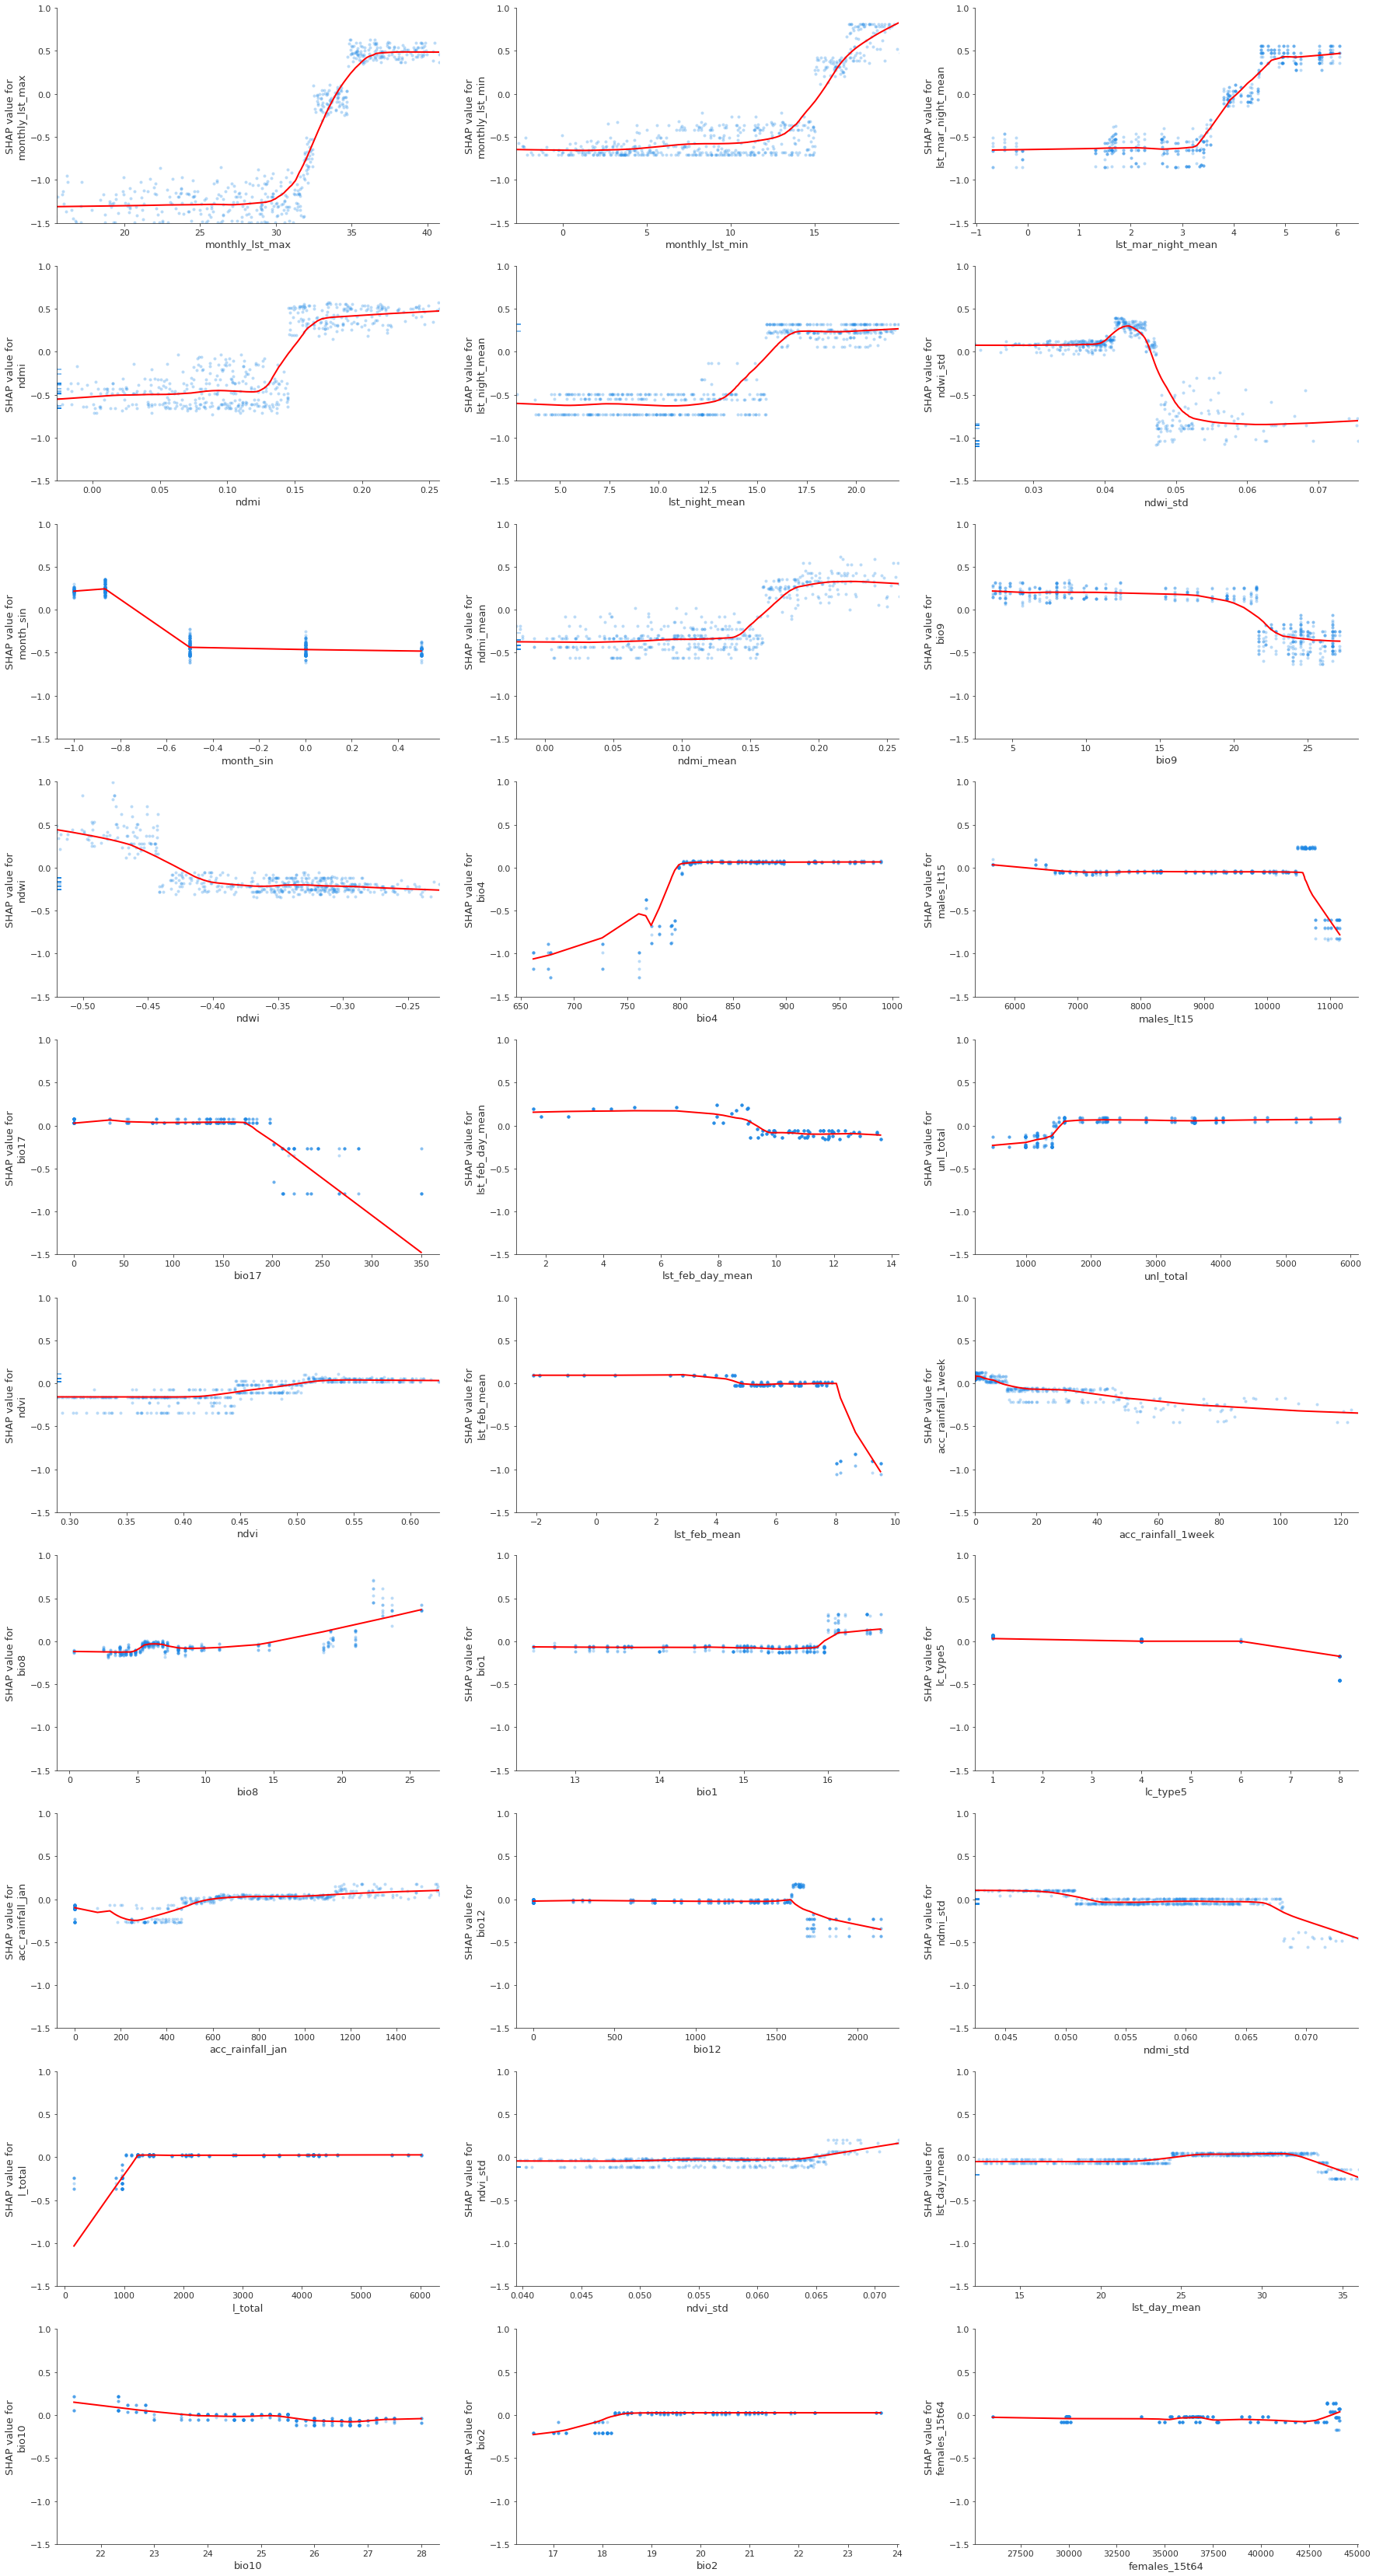

In [73]:
num_plots = 30

fig, axes = plt.subplots(10, 3, figsize=(30, 60))  # Adjust figsize as needed
i = 0

for ft in sorted_mean_abs_values_idx[:num_plots]:
    row = i // 3
    col = i % 3

    ax = axes[row, col]
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2, frac=.3)
    
    ax.plot(*list(zip(*lowess)), color="red", lw=2)
    ax.set_ylim(shap_lim)

    # for tick in ax.get_xticklabels():
    #     tick.set_rotation(60)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values, features=X_train, 
                         feature_names=feature_names, interaction_index=None, 
                         xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax=ax, show = False)
    
    i = i+1

plt.show()

    

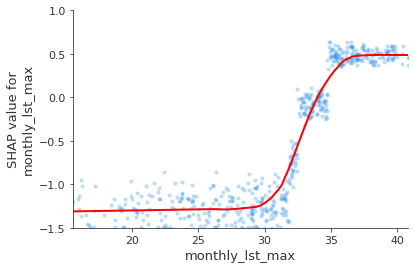

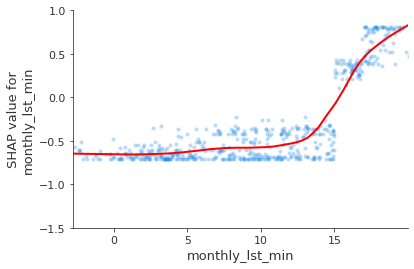

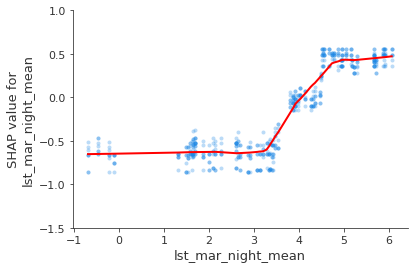

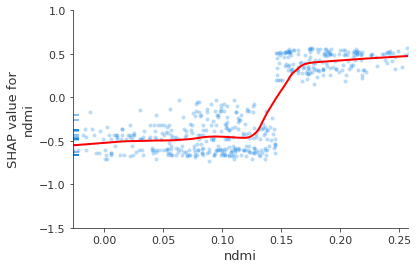

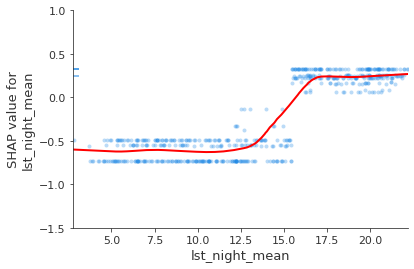

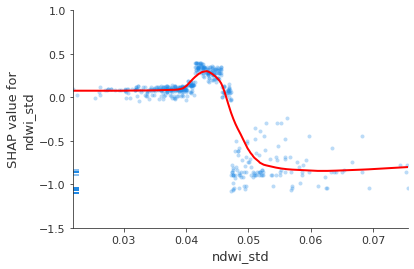

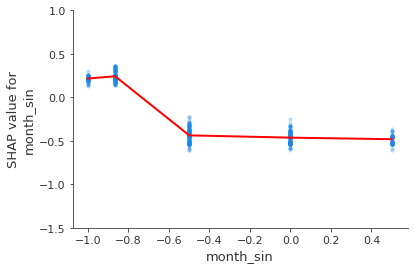

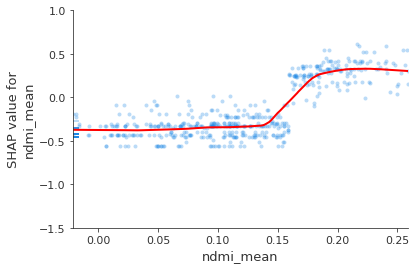

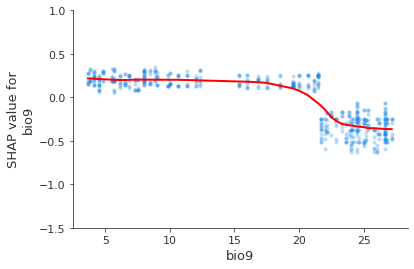

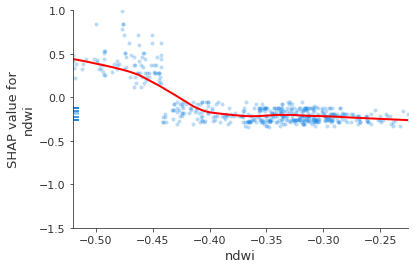

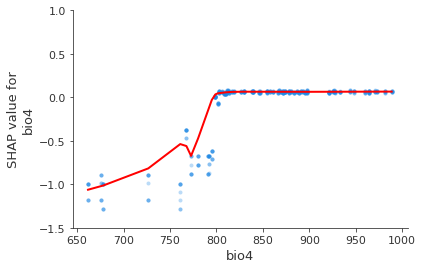

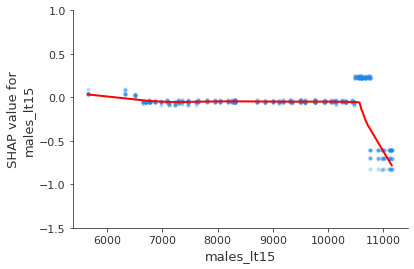

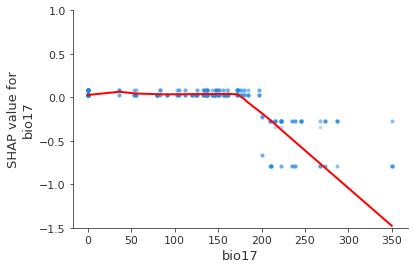

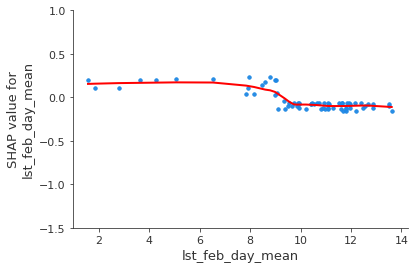

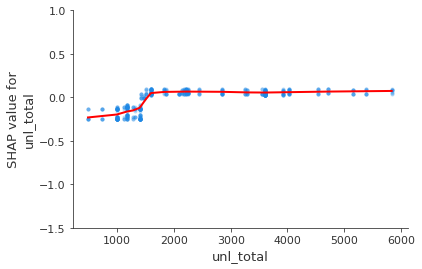

In [74]:
for ft in sorted_mean_abs_values_idx[:15]:
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2,frac=.3)
    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 2)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = X_train, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax = ax)